# 01 - Stage A: data analysis of the SDWPF wind farm

**Project:** *The Answer Is Blowing in the Wind* - forecasting every turbine of a wind farm
from the features of its neighbours, including turbines whose own SCADA data are missing.

**Dataset:** SDWPF (Baidu KDD Cup 2022 release), 245-day / 134-turbine variant
(`sdwpf_245days_v1.csv`, 4 727 520 records, 10-minute resolution), plus relative turbine
coordinates. This is the same variant used by Zhang et al. (2026), so their 70/10/20
day splits and reported baselines stay comparable.

**What this notebook settles** (everything Stage B needs):

| # | Question | Where |
|---|---|---|
| 1 | Is the file complete/consistent, and what do the columns mean? | §1-2 |
| 2 | How is the *absolute* wind direction obtained from `Ndir`/`Wdir`, when `Wdir` is documented as a **relative** angle? | §3 |
| 3 | Which records are missing / unknown / abnormal (dataset rules)? | §4 |
| 4 | What is the farm geometry (columns, spacing) - i.e. what cone radius/angle makes sense? | §5 |
| 5 | How strong and how spatially structured is the power signal? | §6 |
| 6 | How strong are the trivial baselines, and how fast does the wind turn? | §7 |
| 7 | Chronological splits and leakage guards | §8 |

**Not covered here:** the wind-following graph itself (Stage B, notebook 02) and all model
work (Stages C-D).

## 0. Setup

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# locate the repo root (the folder that contains src/) and make the package importable
ROOT = Path.cwd()
while not (ROOT / "src" / "windgnn").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from windgnn import config as C
from windgnn import data as D
from windgnn import graphs as G
from windgnn import viz as V

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print("repo root :", ROOT)
print("data root :", C.DATA_ROOT)
print(f"expected  : {C.N_RECORDS:,} records = {C.N_TURBINES} turbines x {C.N_DAYS} days x {C.STEPS_PER_DAY} steps")

repo root : /home/andreipaduraru/Desktop/GraphML
data root : /home/andreipaduraru/Desktop/GraphML/SDWPF_dataset
expected  : 4,727,520 records = 134 turbines x 245 days x 144 steps


## 1. Dataset inventory

Two releases ship in the SDWPF folder: the 245-day KDD Cup variant (our modelling dataset)
and the two-year full variant (ERA5 weather, reserved for future work). We check both
turbine-coordinate files agree, then load the 245-day table.

In [2]:
for p in sorted(C.DATA_ROOT.rglob("*")):
    if p.is_file():
        print(f"{p.relative_to(C.DATA_ROOT)!s:60s} {p.stat().st_size/1e6:10.1f} MB")

loc = D.load_location(with_elevation=True)
loc_xy_only = D.load_location(with_elevation=False)
assert (loc.index == loc_xy_only.index).all()
assert np.allclose(loc[["x", "y"]].to_numpy(), loc_xy_only[["x", "y"]].to_numpy())
print(f"\nturbine coordinate file(s): {len(loc)} turbines, both variants agree on (x, y)")
loc.head()

.DS_Store                                                           0.0 MB
README                                                              0.0 MB
sdwpf_full/.DS_Store                                                0.0 MB
sdwpf_full/.sdwpf_2001_2112_full.csv.swp                            6.2 MB
sdwpf_full/sdwpf_2001_2112_full.csv                              1705.2 MB
sdwpf_full/sdwpf_2001_2112_full.parquet                           291.7 MB
sdwpf_full/sdwpf_turb_location_elevation.csv                        0.0 MB
sdwpf_kddcup/.DS_Store                                              0.0 MB
sdwpf_kddcup/final_phase_test.zip                                 916.0 MB
sdwpf_kddcup/sdwpf_245days_v1.csv                                 334.3 MB
sdwpf_kddcup/sdwpf_baidukddcup2022_turb_location.csv                0.0 MB

turbine coordinate file(s): 134 turbines, both variants agree on (x, y)


,x,y,Ele
TurbID,,,
1,3349.8515,5939.23193,1430.700073
2,3351.0017,6416.64673,1434.200073
3,3314.7797,6892.18395,1436.900024
4,3352.0940,7366.14203,1439.700073
5,3355.3420,7841.20175,1441.700073


In [3]:
t0 = time.time()
df = D.load_analysis_table()          # builds the parquet cache on first run
print(f"loaded clean analysis table: {df.shape[0]:,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s")
df.head(3)

loaded clean analysis table: 4,727,520 rows x 29 cols in 0.3s


,TurbID,Day,Tmstamp,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv,step,t,timestamp,is_missing,is_zero,is_unknown,is_abnormal,target_valid,wind_dir_abs,wind_dir_flow,wind_from_sin,wind_from_cos,wind_flow_sin,wind_flow_cos,wspd_u,wspd_v
0,1,1,00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2020-01-01 00:00:00,True,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,00:10,6.17,-3.99,30.73,41.80,25.92,1.0,1.0,1.0,-0.25,494.66,1,1,2020-01-01 00:10:00,False,False,False,False,True,21.93,201.93,0.373474,0.927641,-0.373474,-0.927641,2.304332,5.723544
2,1,1,00:20,6.27,-2.18,30.60,41.63,20.91,1.0,1.0,1.0,-0.24,509.76,2,2,2020-01-01 00:20:00,False,False,False,False,True,18.73,198.73,0.321109,0.947042,-0.321109,-0.947042,2.013353,5.937955


In [4]:
checks = pd.DataFrame({
    "check": ["rows", "columns", "turbines", "timestamps per turbine", "duplicate (TurbID, t)",
              "step index range", "days covered", "records per day"],
    "value": [
        f"{len(df):,}", f"{df.shape[1]}",
        f"{df.TurbID.nunique()}", f"{df.groupby('TurbID').size().unique()}",
        f"{int(df.duplicated(['TurbID','t']).sum())}",
        f"{df.step.min()}..{df.step.max()}",
        f"{df.Day.min()}..{df.Day.max()} ({df.Day.nunique()} days)",
        f"{df.groupby('Day').size().unique()}",
    ],
})
checks

,check,value
0,rows,"4,727,520"
1,columns,29
2,turbines,134
3,timestamps per turbine,[35280]
4,"duplicate (TurbID, t)",0
5,step index range,0..143
6,days covered,1..245 (245 days)
7,records per day,[19296]


Two data-availability notes, established while loading:

1. **No calendar date.** The KDD Cup release stores `Day` (1..245) and `Tmstamp` only.
   We tried to recover the real period from the two-year release and could not: its
   timestamp column is internally inconsistent (some days hold 144 rows, others 96) and the
   KDD Cup values do not occur in it. Every timestamp in this project is therefore
   **relative** (`config.RELATIVE_ANCHOR`), which is harmless for chronological splits,
   windowing and per-sector analysis.
2. **Column semantics.** `Wdir` is documented as *the angle between the wind direction and
   the nacelle direction* - i.e. a **relative** angle - while `Ndir` is the nacelle bearing
   from true north. That makes the absolute wind direction a reconstruction problem, which
   §3 resolves; it is the single most important input to the wind-following graph.

## 2. From raw columns to derived features

`data.add_derived` adds the absolute wind direction (assuming a convention), its flow
direction (+180°), sine/cosine encodings, and the `u`/`v` wind-speed components that
paper 1 uses as node features. `data.flag_records` applies the dataset's validity rules.

In [5]:
example = df[df.t.isin([1000, 20000])][["TurbID","Day","Tmstamp","Wspd","Wdir","Ndir",
                                        "wind_dir_abs","wind_dir_flow","wspd_u","wspd_v"]]
example.head(8)

,TurbID,Day,Tmstamp,Wspd,Wdir,Ndir,wind_dir_abs,wind_dir_flow,wspd_u,wspd_v
1000,1,7,22:40,2.85,1.51,439.70,81.21,261.21,2.816527,0.435518
20000,1,139,21:20,1.94,-30.98,-140.23,188.79,8.79,-0.296458,-1.917215
36280,2,7,22:40,3.54,-0.44,437.02,76.58,256.58,3.443340,0.821590
55280,2,139,21:20,2.15,-35.46,189.91,154.45,334.45,0.927292,-1.939750
71560,3,7,22:40,4.34,3.51,287.75,291.26,111.26,-4.044640,1.573687
90560,3,139,21:20,2.13,6.07,11.76,17.83,197.83,0.652193,2.027694
106840,4,7,22:40,3.23,-6.56,456.25,89.69,269.69,3.229953,0.017476
125840,4,139,21:20,2.54,-51.54,218.79,167.25,347.25,0.560571,-2.477369


## 3. The crux: what *is* the wind direction? (TA feedback question 1)

The wind-following graph is defined by "which turbine is upwind of which", so we need one
absolute wind direction per 10-minute snapshot. Three candidate reconstructions were
considered:

* `rel_sum`  - `abs = (Ndir + Wdir) mod 360` (the documentation's reading)
* `rel_diff` - `abs = (Ndir - Wdir) mod 360` (same, opposite sign)
* `absolute` - `Wdir` is itself the absolute direction (`Ndir` unused)

**A naive test fails.** If we simply ask which candidate is most *coherent across turbines*
at a given timestamp, raw `Wdir` wins with R = 0.997 - but only because `Wdir` is
essentially constant: turbines yaw into the wind, which *keeps* the relative angle near 0.
A degenerate near-constant column always looks coherent. The test therefore adds a second
requirement: a real wind direction must follow the weather and therefore **vary a lot over
245 days** (`temporal_R` low).

In [6]:
diag = D.wind_direction_diagnostics(df)
diag.to_csv(C.TABLES_DIR / "stage_a_wind_direction_conventions.csv", index=False)
diag

,convention,description,cross_turbine_R,temporal_R,cross_turbine_R_calibrated
0,absolute,Wdir is already the absolute wind direction (N...,0.997462,0.998406,0.997474
1,rel_sum,absolute direction = Ndir + Wdir (wind side of...,0.468671,0.277750,0.958664
2,rel_diff,absolute direction = Ndir - Wdir (opposite sig...,0.466527,0.274808,0.953552


In [7]:
# Behavioural signature of a RELATIVE angle: turbines yaw into the wind, so the relative
# angle shrinks as the farm gets windier. An absolute direction would have no reason to.
d = df[df.target_valid].copy()
mean_wspd = d.groupby("t", observed=True)["Wspd"].mean()
d["wspd_bin"] = pd.cut(mean_wspd.reindex(d.t).to_numpy(), [0,2,4,6,8,10,30],
                       labels=["0-2","2-4","4-6","6-8","8-10","10+"])
sig = d.groupby("wspd_bin", observed=True).agg(
    n_records=("Wdir", "size"),
    mean_abs_Wdir=("Wdir", lambda s: float(np.nanmean(np.abs(s)))),
    mean_abs_Ndir_centred=("Ndir", lambda s: float(np.nanmean(np.abs(D.wrap180(s - D.circular_median(s.to_numpy())))))),
).round(2)
sig.to_csv(C.TABLES_DIR / "stage_a_wdir_vs_windspeed.csv")
print(sig.to_string())

          n_records  mean_abs_Wdir  mean_abs_Ndir_centred
wspd_bin                                                 
0-2          243610          31.29                  88.97
2-4          976281           5.64                  88.14
4-6          987476           3.07                  80.41
6-8          634435           2.63                  76.52
8-10         383488           2.45                  70.03
10+          370569           2.61                  67.03


Reading the two tables:

* `absolute` is **rejected**: `temporal_R = 0.998`, i.e. it would mean the wind blew from
  the same bearing for 245 days.
* `rel_sum` and `rel_diff` both vary like weather (`temporal_R ≈ 0.28`) - the documented
  relative reading is correct.
* The behavioural table confirms it independently: `mean|Wdir|` falls from ~31° in calm
  conditions to ~2.5° at 10+ m/s, exactly the signature of a yaw-aligned relative angle.

**Chosen convention: `rel_sum`.** The sign (`rel_sum` vs `rel_diff`) is not resolvable from
coherence alone - and, importantly, does not need to be: at operating wind speeds
`|Wdir| ≈ 2.5°`, so the two candidates differ by ≈5°, which is well inside the cone-angle
sensitivity sweep planned for Stage B.

### 3.1 A per-turbine bias in the nacelle bearing

`rel_sum` is only *partly* coherent across turbines (R ≈ 0.47). That is not noise: each
turbine deviates from the farm consensus by a **stable** angle (residual dispersion ≈ 13.5°
around its own median), so a minority of nacelle bearings carry a constant offset. Removing
each turbine's own median deviation raises coherence to ≈ 0.96. We therefore estimate the
farm direction with a robust consensus plus a per-turbine offset table.

> **Leakage guard.** The offsets are fitted on **training days only** and then applied to
> validation/test, so no test-period information enters the wind direction.

In [8]:
train_lo, train_hi = C.SPLIT_DAYS["train"]
train_days = df[(df.Day >= train_lo) & (df.Day <= train_hi)]
print("fitting wind-direction calibration on training days only:", train_lo, "-", train_hi)

_, offsets_train = D.estimate_farm_wind_direction(train_days)
farm, offsets_used = D.estimate_farm_wind_direction(df, offsets=offsets_train)
print(f"\nsnapshots with an estimate : {len(farm):,} of {C.N_STEPS:,}")
print(f"mean cross-turbine coherence: {farm.coherence.mean():.3f}")
print(f"snapshots with coherence<0.5: {int((farm.coherence < 0.5).sum())}")
print(f"direction varies over time  : circular std = {D.circular_std(farm.farm_dir.to_numpy()):.1f} deg")
off_abs = D.wrap180(offsets_used.to_numpy())
print("\nper-turbine yaw offsets (deg): "
      + ", ".join(f"|off|<={t}: {(np.abs(off_abs) <= t).mean()*100:.0f}%" for t in (15, 30, 60, 90)))

fitting wind-direction calibration on training days only: 1 - 171

snapshots with an estimate : 26,610 of 35,280
mean cross-turbine coherence: 0.958
snapshots with coherence<0.5: 26
direction varies over time  : circular std = 89.1 deg

per-turbine yaw offsets (deg): |off|<=15: 28%, |off|<=30: 50%, |off|<=60: 69%, |off|<=90: 73%


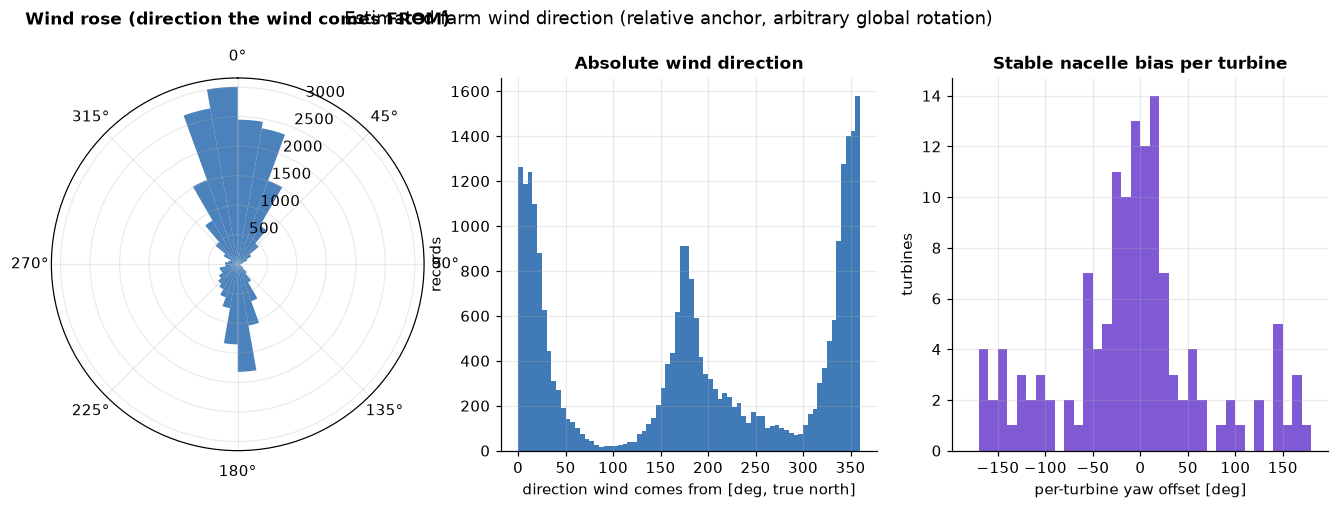

In [9]:
fig = plt.figure(figsize=(15, 4.4))
ax_rose = fig.add_subplot(1, 3, 1, projection="polar")     # wind roses need a polar axes
V.plot_wind_rose(farm.farm_dir.to_numpy(), ax=ax_rose)
V.plot_direction_hist(farm.farm_dir.to_numpy(), ax=fig.add_subplot(1, 3, 2))

ax_off = fig.add_subplot(1, 3, 3)
ax_off.hist(off_abs, bins=36, range=(-180, 180), color="#805ad5")
ax_off.set_xlabel("per-turbine yaw offset [deg]")
ax_off.set_ylabel("turbines")
ax_off.set_title("Stable nacelle bias per turbine")
fig.suptitle("Estimated farm wind direction (relative anchor, arbitrary global rotation)", y=1.02)
V.save_figure(fig, "stage_a_wind_direction")
plt.show()

In [10]:
# Wind-direction persistence: how fast does the direction turn? (motivates per-snapshot graphs)
fd = farm["farm_dir"]
for delta_steps, label in [(1, "10 min"), (6, "1 h"), (36, "6 h"), (144, "1 day")]:
    turn = np.abs(D.wrap180((fd.shift(-delta_steps) - fd).to_numpy()))
    turn = turn[np.isfinite(turn)]
    print(f"{label:>6s}: median turn {np.median(turn):5.1f} deg | share > 30 deg: {(turn > 30).mean()*100:5.1f}%"
          f" | share > 90 deg: {(turn > 90).mean()*100:5.1f}%")

10 min: median turn   2.1 deg | share > 30 deg:   2.6% | share > 90 deg:   0.7%
   1 h: median turn   7.6 deg | share > 30 deg:  12.7% | share > 90 deg:   3.9%
   6 h: median turn  29.6 deg | share > 30 deg:  49.6% | share > 90 deg:  19.0%
 1 day: median turn  39.5 deg | share > 30 deg:  56.6% | share > 90 deg:  34.3%


In [11]:
farm.to_csv(C.INTERIM_DIR / "farm_wind_direction.csv")
offsets_used.rename("yaw_offset_deg").to_csv(C.INTERIM_DIR / "turbine_yaw_offsets.csv")
print("saved: data/interim/farm_wind_direction.csv, data/interim/turbine_yaw_offsets.csv")

saved: data/interim/farm_wind_direction.csv, data/interim/turbine_yaw_offsets.csv


## 4. Record validity (the dataset's own rules)

Validity is what makes this project non-trivial: the turbine we want to predict is often
exactly the one whose data are unusable. Following Zhou et al. (2024) we separate:

| category | rule |
|---|---|
| zero | `Patv < 0` (auxiliary loads) -> clipped to 0 |
| missing | any measurement NaN |
| unknown | `Patv <= 0 and Wspd > 2.5` (turbine stopped) or any `Pab_i > 89°` (blades feathered) |
| abnormal | `Ndir` outside [-720, 720] or `Wdir` outside [-180, 180] |

`target_valid` = none of missing/unknown/abnormal. Paper 3 reports, for the two-year file,
28.7% zeros, 4.4% missing, 22.6% unknown and 141 abnormal records; our 245-day figures
should be in the same ballpark.

In [12]:
flags = pd.DataFrame({
    "category": ["zero (Patv<0)", "missing (any NaN)", "unknown (stopped/feathered)", "abnormal (Ndir/Wdir range)", "target_valid"],
    "records": [int(df.is_zero.sum()), int(df.is_missing.sum()), int(df.is_unknown.sum()),
                int(df.is_abnormal.sum()), int(df.target_valid.sum())],
})
flags["share_%"] = (flags.records / len(df) * 100).round(2)
flags.to_csv(C.TABLES_DIR / "stage_a_record_validity.csv", index=False)
flags

,category,records,share_%
0,zero (Patv<0),1263062,26.72
1,missing (any NaN),49518,1.05
2,unknown (stopped/feathered),1082113,22.89
3,abnormal (Ndir/Wdir range),127,0.00
4,target_valid,3595859,76.06


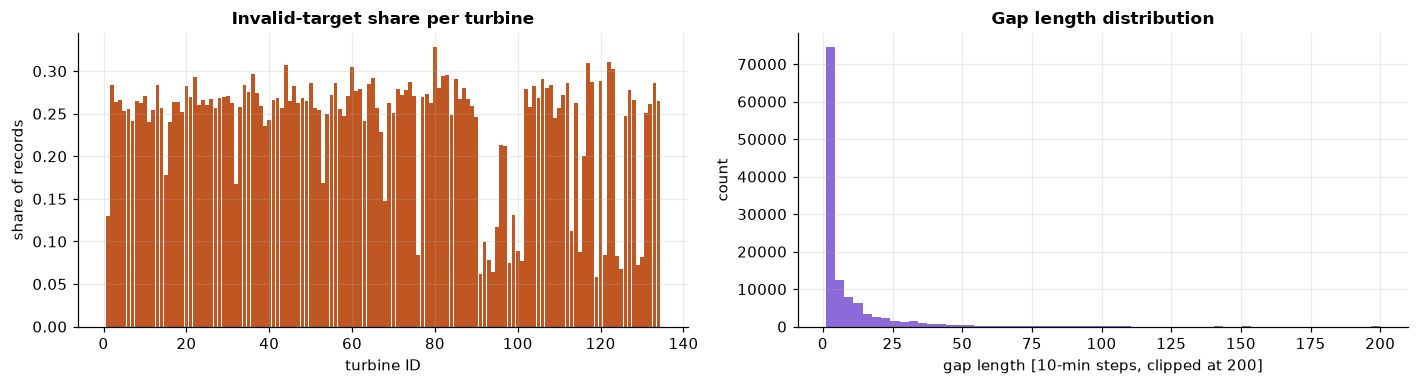

contiguous invalid gaps: n=121,012 | median=3 steps | p99=92 | longest=2861 steps (19.9 days)
share of turbines with an invalid rate above 30%: 4.5%


In [13]:
# Per-turbine invalid share, and the length of contiguous invalid gaps (feeds outage scenario iii)
rates = (df.assign(bad=~df.target_valid).groupby("TurbID", observed=True)["bad"].mean())
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
V.plot_missingness_by_turbine(rates, ax=axes[0], title="Invalid-target share per turbine")

def gap_lengths(mask):
    m = np.asarray(mask, dtype=bool)
    if m.all():
        return np.array([m.size])
    idx = np.flatnonzero(np.diff(np.concatenate([[0], m.view(np.int8), [0]])))
    return (idx[1::2] - idx[::2])

gl = np.concatenate([gap_lengths(g.sort_values("t")["target_valid"].to_numpy() == False)
                     for _, g in df.groupby("TurbID", observed=True)])
V.plot_gap_histogram(gl, ax=axes[1])
fig.tight_layout()
V.save_figure(fig, "stage_a_validity")
plt.show()
print(f"contiguous invalid gaps: n={len(gl):,} | median={np.median(gl):.0f} steps | p99={np.percentile(gl,99):.0f}"
      f" | longest={gl.max()} steps ({gl.max()*10/60/24:.1f} days)")
print(f"share of turbines with an invalid rate above 30%: {(rates > 0.30).mean()*100:.1f}%")

## 5. Farm geometry: what cone radius and angle are plausible?

This decides the Stage B graph hyperparameters. From the 134 turbine positions we recover the
column structure, the spacing within and between columns, and the extent.

In [14]:
ext = G.extent(loc)
col = G.detect_columns(loc)
print(ext)
print(f"\ncolumns detected: {len(np.unique(col))} of sizes {np.bincount(col).tolist()}")
print("note: Zhang et al. (2026) report FIVE longitudinal columns - our gap-based detection")
print("      finds six strips of ~22 turbines; this discrepancy is worth flagging in the report.")
spacing = G.spacing_summary(loc)
spacing.round(1).to_csv(C.TABLES_DIR / "stage_a_spacing.csv", index=False)
spacing.round(1)

{'n_turbines': 134, 'x_span_m': 5501.4529, 'y_span_m': 12121.00426, 'x_range': (0.0, 5501.4529), 'y_range': (0.0, 12121.00426)}

columns detected: 6 of sizes [22, 22, 22, 24, 23, 21]
note: Zhang et al. (2026) report FIVE longitudinal columns - our gap-based detection
      finds six strips of ~22 turbines; this discrepancy is worth flagging in the report.


,neighbour_group,count,min,p25,median,p75,max
0,within_column,134,406.6,470.3,474.1,475.7,542.9
1,across_columns,134,888.1,968.8,991.3,1010.5,1471.5
2,any,134,406.6,470.3,474.1,475.7,542.9


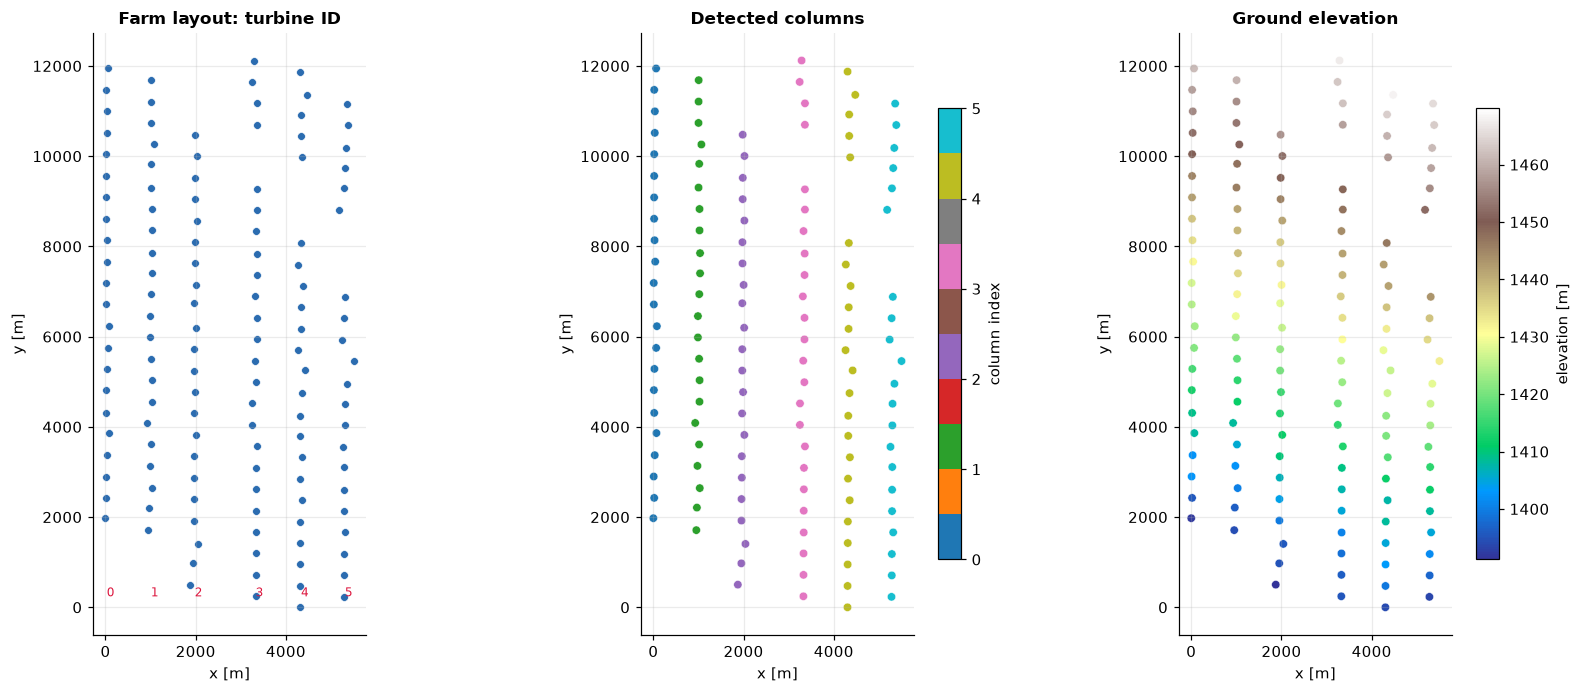

distance matrix: median pair distance 4501 m, max 12823 m (= 12.8 km)
rotor diameter 82 m -> within-column spacing is ~5.8 D, between columns ~12.1 D


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.4))
V.plot_layout(loc, ax=axes[0], title="Farm layout: turbine ID")
for c in np.unique(col):
    sub = loc[col == c]
    axes[0].annotate(str(c), (sub.x.mean(), loc.y.max()*0.02), fontsize=8, color="crimson")

V.plot_layout(loc, values=col, ax=axes[1], title="Detected columns", cbar_label="column index", cmap="tab10")
V.plot_layout(loc, values=loc["Ele"].to_numpy(), ax=axes[2], title="Ground elevation",
              cbar_label="elevation [m]", cmap="terrain")
fig.tight_layout()
V.save_figure(fig, "stage_a_layout")
plt.show()

d = G.pairwise_distances(loc)
print(f"distance matrix: median pair distance {np.median(d[np.triu_indices_from(d,1)]):.0f} m,"
      f" max {d.max():.0f} m (= {d.max()/1000:.1f} km)")
print(f"rotor diameter {C.ROTOR_DIAMETER_M:.0f} m -> within-column spacing is ~{474/82:.1f} D,"
      f" between columns ~{991/82:.1f} D")

**Consequence for Stage B:** within-column spacing is ~474 m and between-column ~991 m, so a
cone radius in the 600-1500 m range captures the same-column and adjacent-column neighbours
that dominate wake interaction, while staying far below the 12 km farm extent. The
sensitivity sweep (R ∈ {600, 1000, 1500, 3000} m; φ ∈ {15°, 30°, 45°, 60°}) is set around
these numbers.

## 6. Power signal and spatial correlation

Numbers to reproduce from Zhang et al. (2026, §4.1-4.2): farm mean power 349.3 kW,
per-turbine mean 243-439 kW, power std 350-500 kW (mean 420.6), average shutdown ratio 2.6%,
mean inter-turbine correlation 0.937, minimum (most distant pair) 0.812, correlation-vs-distance
regression R² = 0.527, r > 0.9 below 1000 m and r < 0.8 beyond 5000 m.

> **Definitional note.** Those published figures only reproduce when *invalid*
> records are kept (farm mean 350.5 kW over all records vs 456.0 kW over valid
> targets). Each metric below therefore states which definition it uses.

In [16]:
patv = D.power_wide(df, "Patv", valid_only=True)
print(f"valid power matrix: {patv.shape[0]:,} timestamps x {patv.shape[1]} turbines")
per_turb = patv.mean()
farm_mean = np.nanmean(patv.to_numpy())
std = patv.std()
shutdown = (df.assign(s=df.target_valid & (df.Patv <= 0)).groupby("TurbID", observed=True)["s"].mean())

stats = pd.Series({
    "farm mean power [kW]": farm_mean,
    "per-turbine mean: min": per_turb.min(), "per-turbine mean: max": per_turb.max(),
    "per-turbine std: min": std.min(), "per-turbine std: max": std.max(), "per-turbine std: mean": std.mean(),
    "shutdown ratio (mean over turbines)": shutdown.mean(),
    "capacity factor (farm)": farm_mean / C.RATED_POWER_KW,
}).round(2)
stats.to_csv(C.TABLES_DIR / "stage_a_power_stats.csv")
print(stats.to_string())

valid power matrix: 35,015 timestamps x 134 turbines
farm mean power [kW]                   456.03
per-turbine mean: min                  268.49
per-turbine mean: max                  562.75
per-turbine std: min                   327.56
per-turbine std: max                   530.05
per-turbine std: mean                  426.65
shutdown ratio (mean over turbines)      0.06
capacity factor (farm)                   0.30


inter-turbine power correlation: mean 0.896 | min 0.717 | max 0.987


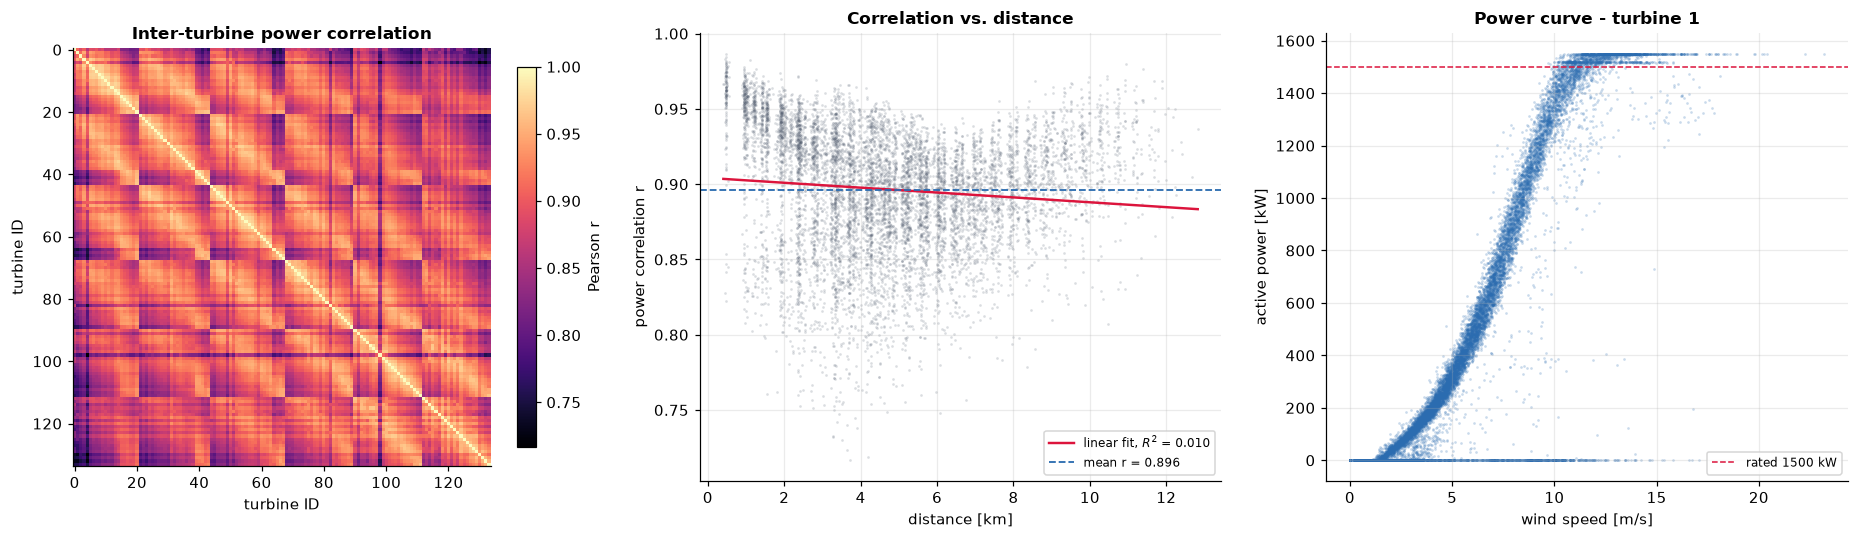

In [17]:
corr = patv.corr(min_periods=500).to_numpy()
iu = np.triu_indices_from(corr, k=1)
print(f"inter-turbine power correlation: mean {np.nanmean(corr[iu]):.3f} | min {np.nanmin(corr[iu]):.3f}"
      f" | max {np.nanmax(corr[iu]):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5.0))
V.plot_correlation_matrix(corr, ax=axes[0])
V.plot_correlation_vs_distance(d, corr, ax=axes[1])
V.plot_power_curve(df, turbine=1, ax=axes[2])
fig.tight_layout()
V.save_figure(fig, "stage_a_correlation")
plt.show()

In [18]:
dist_km = d[iu] / 1000.0
r = corr[iu]
ok = np.isfinite(r)
for lo, hi in [(0, 1), (1, 2), (2, 3), (3, 5), (5, 8), (8, 13)]:
    m = ok & (dist_km >= lo) & (dist_km < hi)
    if m.any():
        print(f"distance {lo}-{hi} km: mean r = {r[m].mean():.3f} (n pairs = {m.sum()})")
print("\n=> if correlation stays high everywhere, a FIXED graph is a strong baseline:")
print("   the direction-blind control (cone 180 deg) in Stage C/D is what makes H1 falsifiable.")

distance 0-1 km: mean r = 0.944 (n pairs = 290)
distance 1-2 km: mean r = 0.922 (n pairs = 942)
distance 2-3 km: mean r = 0.900 (n pairs = 1144)
distance 3-5 km: mean r = 0.886 (n pairs = 2747)
distance 5-8 km: mean r = 0.886 (n pairs = 2718)
distance 8-13 km: mean r = 0.910 (n pairs = 1070)

=> if correlation stays high everywhere, a FIXED graph is a strong baseline:
   the direction-blind control (cone 180 deg) in Stage C/D is what makes H1 falsifiable.


In [19]:
# Correlation depends on *position along the flow*, not only on distance: two turbines in the
# same column can sit 12 km apart (upstream/downstream of each other) yet stay strongly
# correlated, while nearby pairs in different columns need not be. That is precisely why a
# plain distance-kNN graph is a weak baseline for this farm.
col_of = G.detect_columns(loc)
same_col = col_of[:, None] == col_of[None, :]
for group, mask in [("same column", same_col), ("different columns", ~same_col)]:
    m = mask[iu] & np.isfinite(r)
    print(f"{group:>18s}: mean r = {r[m].mean():.3f} (n pairs = {m.sum()})")

rho = np.abs(loc["y"].to_numpy()[:, None] - loc["y"].to_numpy()[None, :])  # separation along a column
print("\nsame-column pairs: correlation vs. separation along the column")
for lo, hi in [(0, 500), (500, 1000), (1000, 2000), (2000, 4000), (4000, 8000), (8000, 13000)]:
    m = same_col[iu] & np.isfinite(r) & (rho[iu] >= lo) & (rho[iu] < hi) & (np.abs(d[iu] - rho[iu]) < 300)
    if m.sum() > 5:
        print(f"  along-column separation {lo/1000:4.1f}-{hi/1000:4.1f} km: mean r = {r[m].mean():.3f} (n = {m.sum()})")

       same column: mean r = 0.912 (n pairs = 1432)
 different columns: mean r = 0.893 (n pairs = 7479)

same-column pairs: correlation vs. separation along the column
  along-column separation  0.0- 0.5 km: mean r = 0.953 (n = 114)
  along-column separation  0.5- 1.0 km: mean r = 0.938 (n = 124)
  along-column separation  1.0- 2.0 km: mean r = 0.920 (n = 213)
  along-column separation  2.0- 4.0 km: mean r = 0.898 (n = 364)
  along-column separation  4.0- 8.0 km: mean r = 0.898 (n = 473)
  along-column separation  8.0-13.0 km: mean r = 0.931 (n = 144)


In [20]:
# Reconcile the power statistics with Zhang et al. (2026). Their figures (farm mean 349.3 kW,
# per-turbine 243-439 kW) reproduce only if *invalid* records are kept, because they describe
# raw sensor output rather than the valid-target subset this project models.
recon = pd.DataFrame({
    "definition": ["all records (negatives clipped to 0)", "target_valid records only"],
    "farm_mean_kW": [float(df.Patv.mean()), float(df.loc[df.target_valid, "Patv"].mean())],
    "per_turbine_min_kW": [float(df.groupby("TurbID", observed=True).Patv.mean().min()),
                           float(df[df.target_valid].groupby("TurbID", observed=True).Patv.mean().min())],
    "per_turbine_max_kW": [float(df.groupby("TurbID", observed=True).Patv.mean().max()),
                           float(df[df.target_valid].groupby("TurbID", observed=True).Patv.mean().max())],
}).round(1)
print(recon.to_string(index=False))
print("\nZhang et al. report 349.3 kW / 243-439 kW -> matches the 'all records' row (350.5 kW /")
print("244-463 kW). Their numbers include stopped and invalid records; every metric reported in")
print("this project will state which definition it uses.")
print("\nOur mean inter-turbine r (0.896) is below their 0.937 because we correlate valid records")
print("only and require 500 overlapping samples. The conclusion is unchanged: r stays above 0.88")
print("at every distance, so a fixed graph is a serious baseline for H1.")

                          definition  farm_mean_kW  per_turbine_min_kW  per_turbine_max_kW
all records (negatives clipped to 0)         350.5               244.1               462.6
           target_valid records only         456.0               268.5               562.8

Zhang et al. report 349.3 kW / 243-439 kW -> matches the 'all records' row (350.5 kW /
244-463 kW). Their numbers include stopped and invalid records; every metric reported in
this project will state which definition it uses.

Our mean inter-turbine r (0.896) is below their 0.937 because we correlate valid records
only and require 500 overlapping samples. The conclusion is unchanged: r stays above 0.88
at every distance, so a fixed graph is a serious baseline for H1.


## 7. How strong are the trivial baselines, and does the wind actually turn?

The persistence error as a function of horizon is the honest floor for H1: if persistence
degrades slowly, a "missing turbine" is best served by copying its own last known value,
and any graph model must beat that.

In [21]:
arr = patv.to_numpy()
errs = {"MAE [kW]": {}, "RMSE [kW]": {}}
for h in [1, 2, 3, 6, 12, 18, 36, 72, 144]:
    a = arr[:-h]
    b = arr[h:]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        continue
    diff = b[m] - a[m]
    errs["MAE [kW]"][h] = float(np.mean(np.abs(diff)))
    errs["RMSE [kW]"][h] = float(np.sqrt(np.mean(diff ** 2)))
pers = pd.DataFrame(errs)
pers.index.name = "horizon_steps"
pers["horizon_label"] = ["10 min", "20 min", "30 min", "1 h", "2 h", "3 h", "6 h", "12 h", "1 day"]
pers.to_csv(C.TABLES_DIR / "stage_a_persistence.csv")
pers.round(2)

,MAE [kW],RMSE [kW],horizon_label
horizon_steps,,,
1,77.66,129.06,10 min
2,107.03,172.01,20 min
3,127.70,200.86,30 min
6,173.31,262.56,1 h
12,230.33,335.91,2 h
18,266.84,382.04,3 h
36,334.91,463.31,6 h
72,391.41,525.43,12 h
144,425.41,565.85,1 day


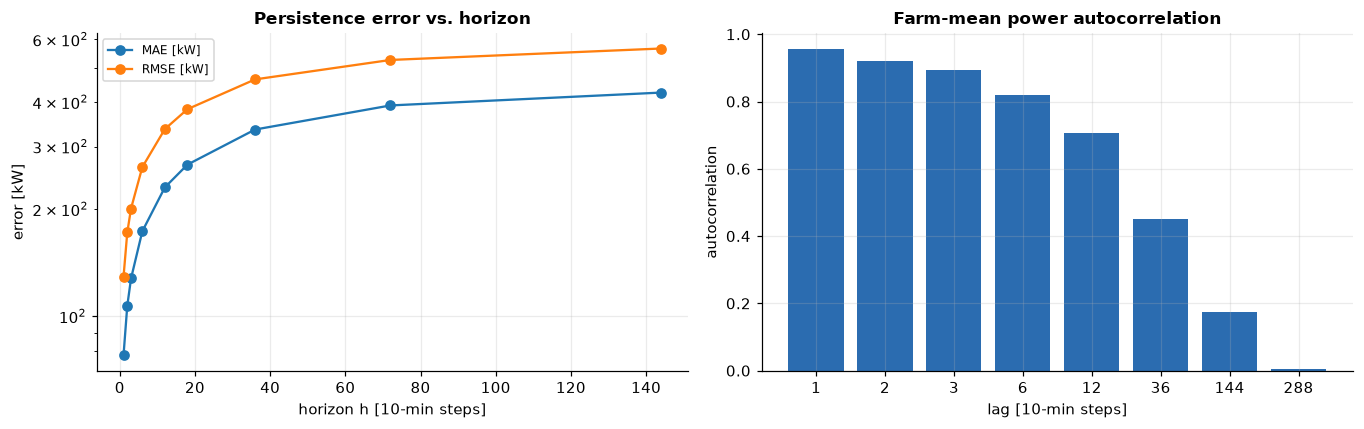

,lag_steps,autocorr
0,1,0.955468
1,2,0.921167
2,3,0.892803
3,6,0.818311
4,12,0.706714
5,36,0.451839
6,144,0.173509
7,288,0.004417


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
V.plot_persistence_error(errs, ax=axes[0])
ac = []
for lag in [1, 2, 3, 6, 12, 36, 144, 288]:
    a = arr[:-lag]; b = arr[lag:]
    m = np.isfinite(a) & np.isfinite(b)
    ac.append({"lag_steps": lag, "autocorr": float(np.corrcoef(a[m], b[m])[0, 1])})
ac = pd.DataFrame(ac)
axes[1].bar(ac.lag_steps.astype(str), ac.autocorr, color="#2b6cb0")
axes[1].set_xlabel("lag [10-min steps]"); axes[1].set_ylabel("autocorrelation")
axes[1].set_title("Farm-mean power autocorrelation")
fig.tight_layout()
V.save_figure(fig, "stage_a_persistence")
plt.show()
ac

## 8. Chronological splits and leakage guards

Zhang et al. (2026) use days 1-171 / 172-196 / 197-245 (70/10/20). Every later stage reuses
exactly these boundaries, and any windowed sample must keep a purge gap of `T + h_max`
steps at each boundary so that no input window or target crosses a split.

In [23]:
rows = []
for name in ["train", "val", "test"]:
    lo, hi = D.split_bounds(name)
    days = C.SPLIT_DAYS[name]
    mask = (df.t >= lo) & (df.t <= hi)
    rows.append({"split": name, "days": f"{days[0]}-{days[1]}", "t_min": lo, "t_max": hi,
                 "share_%": round(mask.mean() * 100, 1),
                 "valid_target_%": round(df.loc[mask, "target_valid"].mean() * 100, 1)})
splits = pd.DataFrame(rows)
splits.to_csv(C.TABLES_DIR / "stage_a_splits.csv", index=False)
splits

,split,days,t_min,t_max,share_%,valid_target_%
0,train,1-171,0,24623,69.8,77.2
1,val,172-196,24624,28223,10.2,72.5
2,test,197-245,28224,35279,20.0,73.7


## 9. Stage A summary

**Data.** 4 727 520 records, 134 turbines x 245 days x 144 steps, no duplicates, both
coordinate files agree. The KDD Cup release has **no calendar date**, and the two-year
release cannot supply one (inconsistent timestamps, non-matching values) - all time indices
are relative.

**Wind direction (the crux).** `Wdir` is a *relative* angle; the absolute direction is
`(Ndir + Wdir) mod 360`. Raw `Wdir` is rejected as an absolute direction because it is
essentially constant over 245 days. A stable per-turbine nacelle bias remains, so the farm
direction is estimated as a robust consensus with a per-turbine offset table fitted on
**training days only** (coherence 0.47 -> 0.96). The sign convention is unresolvable from
coherence alone but immaterial: at operating wind speeds `|Wdir| ≈ 2.5°`, so the two
candidates differ by ~5°, inside the planned cone-angle sweep.

**Validity.** ~24% of records have no usable target (missing + unknown + abnormal), and
farm-wide gaps occur, so "no neighbours left" is a real regime to test - matching outage
scenario (iii).

**Geometry.** Six columns of ~22 turbines, ~474 m spacing within a column, ~991 m between
columns, 5.5 x 12.1 km extent. Cone radius 600-1500 m is the sensible starting range.
(Paper 2 reports five columns - discrepancy to flag.)

**Correlation.** Inter-turbine power correlation is high at all distances, which is exactly
the risk the proposal already names: a fixed distance graph may match the wind-following
graph. The direction-blind control therefore carries the scientific weight of H1.

**Baselines.** Persistence error grows with horizon (see §7) - the floor every model must beat.

**Hand-off to Stage B:** turbine coordinates, `farm_dir` per snapshot (up to a global
rotation, which is absorbed into the farm's axis orientation), the offset table, the
validity masks, and the spacing statistics that set `R` and `φ`.